In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# Dataset Without Truncation

In [17]:
df = pd.read_csv("weather_classification_data.csv")
df['Was_Rain'] = 0
df.loc[df['Weather Type'] == 'Rainy' , 'Was_Rain'] = 1
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type,Was_Rain
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy,1
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy,0
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny,0
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny,0
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy,1


In [19]:
print(df.dtypes)

Temperature             float64
Humidity                  int64
Wind Speed              float64
Precipitation (%)       float64
Cloud Cover              object
Atmospheric Pressure    float64
UV Index                  int64
Season                   object
Visibility (km)         float64
Location                 object
Weather Type             object
Was_Rain                  int64
dtype: object


In [21]:
df.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Was_Rain
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917,0.250000
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499,0.433029
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000,0.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000,0.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000,0.250000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000,1.000000


In [23]:
df = df[ (df["Temperature"] >= -20) &
    (df["Temperature"] <= 55) & (df["Atmospheric Pressure"] <= 1083) & (df["Atmospheric Pressure"] >= 870)]

Looks like there may be an anomoly in temperature as 109 degrees was the maximum which is higher than the highest recorded temp ever. Precipitation % and humidity also seem to have anomolies as max is 109%.


In [26]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 12343 entries, 0 to 13199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           12343 non-null  float64
 1   Humidity              12343 non-null  int64  
 2   Wind Speed            12343 non-null  float64
 3   Precipitation (%)     12343 non-null  float64
 4   Cloud Cover           12343 non-null  object 
 5   Atmospheric Pressure  12343 non-null  float64
 6   UV Index              12343 non-null  int64  
 7   Season                12343 non-null  object 
 8   Visibility (km)       12343 non-null  float64
 9   Location              12343 non-null  object 
 10  Weather Type          12343 non-null  object 
 11  Was_Rain              12343 non-null  int64  
dtypes: float64(5), int64(3), object(4)
memory usage: 1.2+ MB


Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
Was_Rain                0
dtype: int64

There are no missing values in this data.

Next check there are no spelling errors in categorical variables.

In [30]:
for i in ['Cloud Cover', 'Season' , 'Location' , 'Weather Type']:
    print(i,':' , df[i].unique())

Cloud Cover : ['partly cloudy' 'clear' 'overcast' 'cloudy']
Season : ['Winter' 'Spring' 'Summer' 'Autumn']
Location : ['inland' 'mountain' 'coastal']
Weather Type : ['Rainy' 'Cloudy' 'Sunny' 'Snowy']


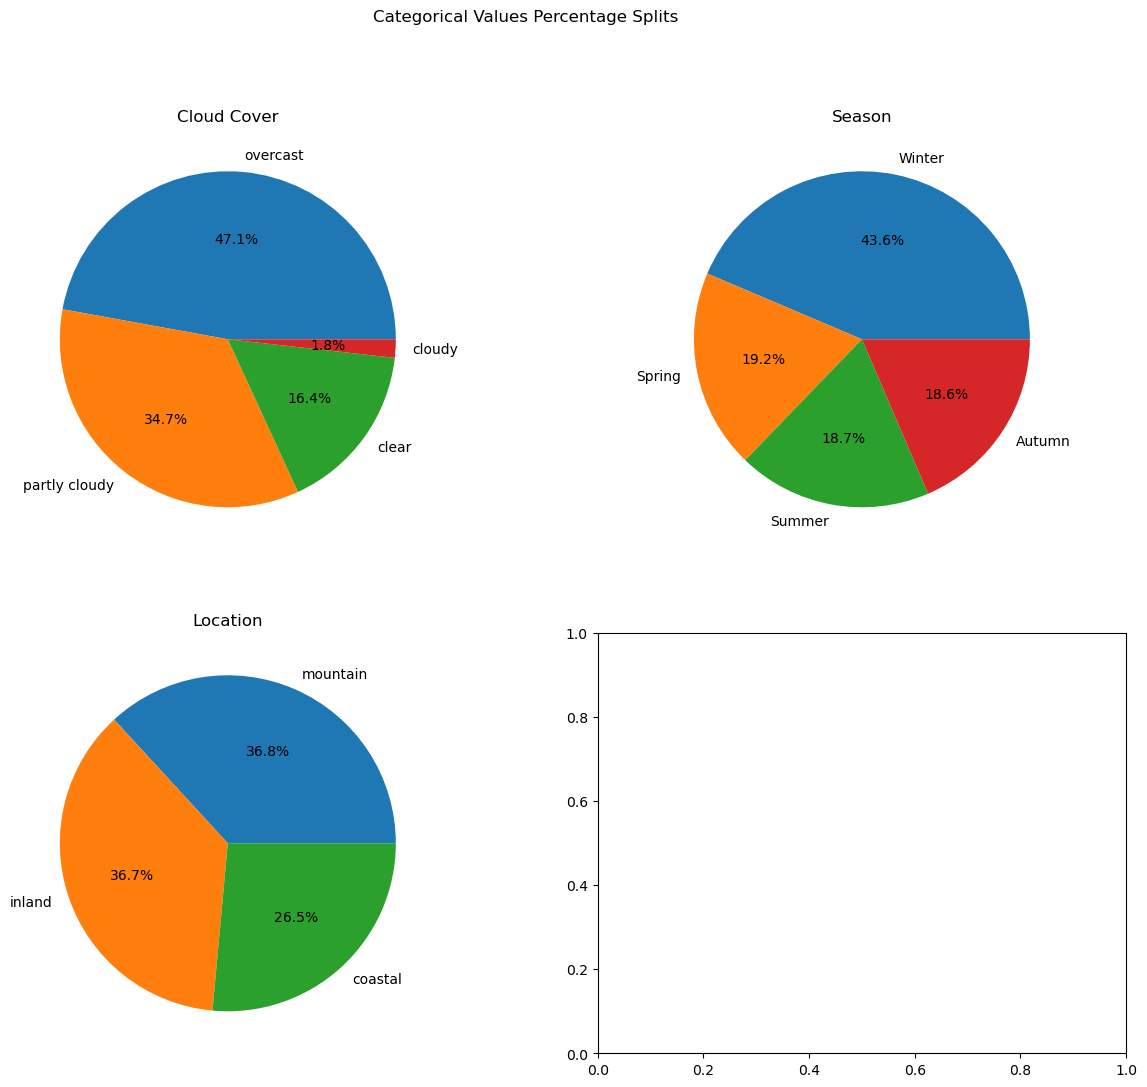

In [32]:
fig, ax = plt.subplots(2, 2,figsize=(15,12))
cloud_counts = df['Cloud Cover'].value_counts()
season_counts = df['Season'].value_counts()
location_counts = df['Location'].value_counts()
fig.suptitle("Categorical Values Percentage Splits")
ax1 = cloud_counts.plot(kind="pie",autopct="%1.1f%%", ax = ax [0,0])
ax1.set_ylabel("")
ax1.set_title("Cloud Cover")
ax2 = season_counts.plot(kind="pie", autopct="%1.1f%%",ax = ax [0,1])
ax2.set_ylabel("")
ax2.set_title("Season")
ax3 = location_counts.plot(kind = 'pie' , autopct="%1.1f%%", ax = ax[1,0])
ax3.set_ylabel("")
ax3.set_title("Location")
plt.show()


## Transforming Categorical Variables

In [34]:
df["Cloud Cover"] = pd.Categorical(
    df["Cloud Cover"],
    categories=["clear", "partly cloudy", "cloudy", "overcast"],
    ordered=True
)

df["cloud_cover"] = df["Cloud Cover"].cat.codes
df.drop(columns = ["Cloud Cover", "Weather Type"] , inplace = True)

In [35]:
df = pd.get_dummies(df, columns=["Season", "Location"], dtype=int)

In [39]:
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Was_Rain,cloud_cover,Season_Autumn,Season_Spring,Season_Summer,Season_Winter,Location_coastal,Location_inland,Location_mountain
0,14.0,73,9.5,82.0,1010.82,2,3.5,1,1,0,0,0,1,0,1,0
1,39.0,96,8.5,71.0,1011.43,7,10.0,0,1,0,1,0,0,0,1,0
2,30.0,64,7.0,16.0,1018.72,5,5.5,0,0,0,1,0,0,0,0,1
3,38.0,83,1.5,82.0,1026.25,7,1.0,0,0,0,1,0,0,1,0,0
4,27.0,74,17.0,66.0,990.67,1,2.5,1,3,0,0,0,1,0,0,1


## Outlier Exploration

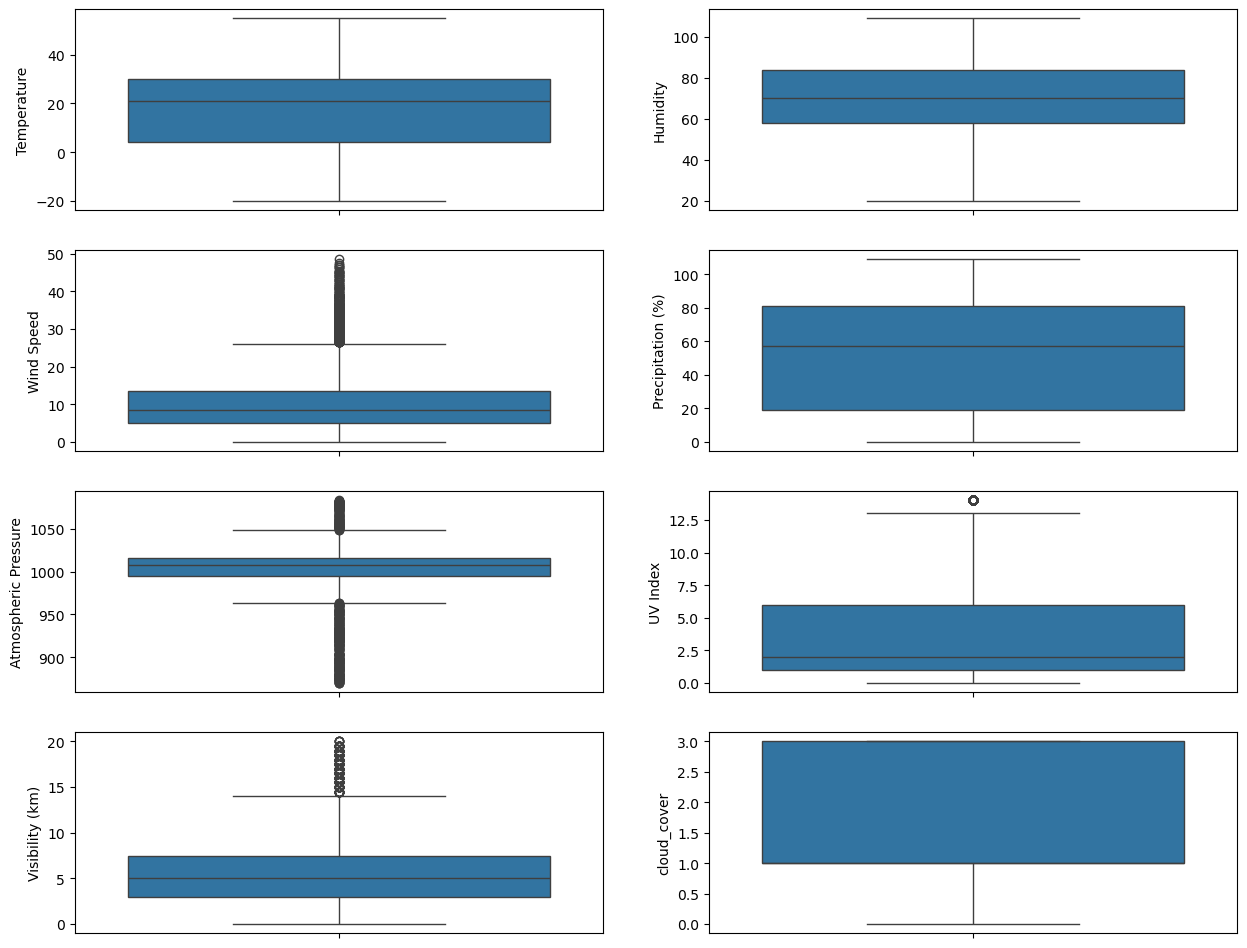

In [42]:
fig, ax = plt.subplots(4, 2,figsize=(15,12))
ax1 = sns.boxplot(y = "Temperature", data = df,  ax = ax[0,0])
ax1.set_ylabel("Temperature")
ax2 = sns.boxplot(y = "Humidity" , data = df,  ax = ax[0,1])
ax3 = sns.boxplot(y = "Wind Speed" , data = df,  ax = ax[1,0])
ax4 = sns.boxplot(y = "Precipitation (%)" , data = df,  ax = ax[1,1])
ax5 = sns.boxplot(y = "Atmospheric Pressure" , data = df,  ax = ax[2,0])
ax6 = sns.boxplot(y = "UV Index" , data = df,  ax = ax[2,1])
ax7 = sns.boxplot(y = "Visibility (km)" , data = df,  ax = ax[3,0])
ax8 = sns.boxplot(y = "cloud_cover" , data = df,  ax = ax[3,1])

Temperature, Wind Speed, Pressure and Visibility are showing outliers. First investigate Temperature outliers.

<Axes: xlabel='Temperature', ylabel='Count'>

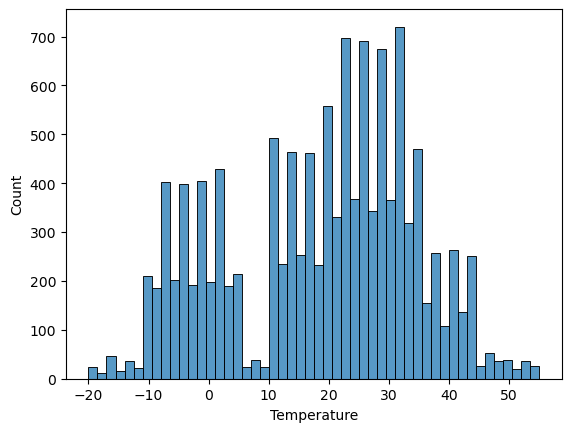

In [44]:
sns.histplot(data = df, x = 'Temperature', bins = 50)

In [47]:
df['Temperature'].skew()

-0.29159258529261195

In [49]:
len_b = len(df)
Q1 = df["Temperature"].quantile(0.25)
Q3 = df["Temperature"].quantile(0.75)
IQR = Q3 - Q1
len_a = len(df[ (df["Temperature"] >= Q1 - (1.5 * IQR)) &
    (df["Temperature"] <= Q3 + (1.5 * IQR))])

len_c = len(df[ (df["Temperature"] >= -20) &
    (df["Temperature"] <= 55)])
len_b , len_a, len_c


(12343, 12343, 12343)

Here I wanted to check how many data points remain unaffected if I did remove those that are classed as "Outliers". I found that there are only 92 outliers which is only 0.13%.

<Axes: xlabel='Wind Speed', ylabel='Count'>

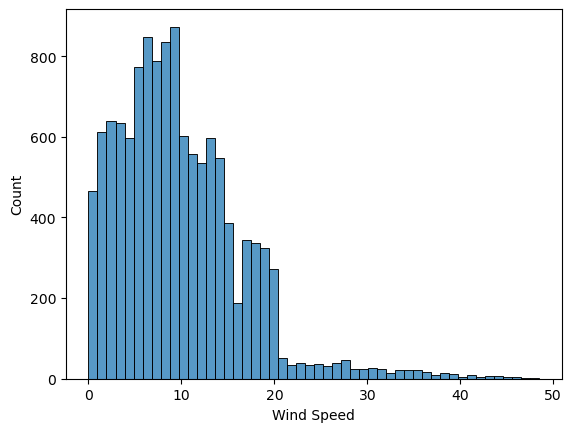

In [52]:
sns.histplot(data = df, x = 'Wind Speed', bins = 50)

Right skew

In [55]:
df['Wind Speed'].skew()

1.3442887597379556

In [57]:
len_b = len(df)
Q1 = df["Wind Speed"].quantile(0.25)
Q3 = df["Wind Speed"].quantile(0.75)
IQR = Q3 - Q1
len_a = len(df[ (df["Wind Speed"] >= Q1 - (1.5 * IQR)) &
    (df["Wind Speed"] <= Q3 + (1.5 * IQR))])
print(len_b , len_a )
print((100 * (len_b - len_a) / len_b) , '%')

12343 11984
2.9085311512598233 %


This time 3% of the data are outliers. 

<Axes: xlabel='Visibility (km)', ylabel='Count'>

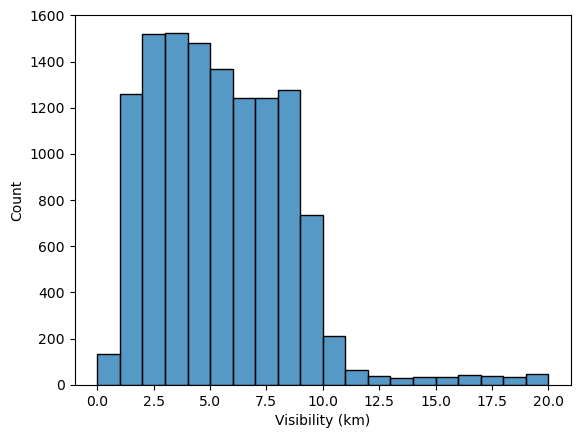

In [60]:
sns.histplot(data = df, x = 'Visibility (km)', bins = 20)

In [62]:
df['Visibility (km)'].skew()

1.078475426792359

In [64]:
len_b = len(df)
Q1 = df["Visibility (km)"].quantile(0.25)
Q3 = df["Visibility (km)"].quantile(0.75)
IQR = Q3 - Q1
len_a = len(df[ (df["Visibility (km)"] >= Q1 - (1.5 * IQR)) &
    (df["Visibility (km)"] <= Q3 + (1.5 * IQR))])
print(len_b , len_a )
print((100 * (len_b - len_a) / len_b) , '%')

12343 12133
1.701369197115774 %


<Axes: xlabel='Atmospheric Pressure', ylabel='Count'>

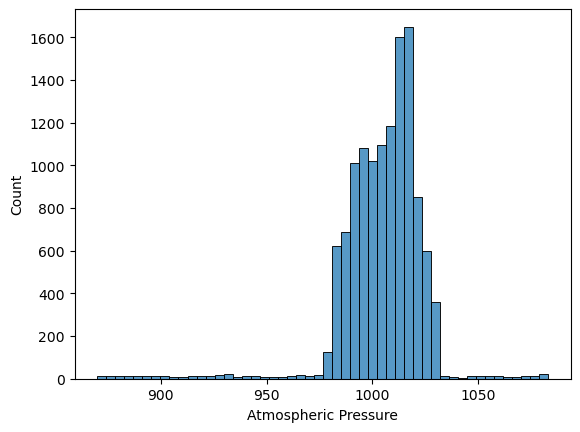

In [66]:
sns.histplot(data = df, x = 'Atmospheric Pressure', bins = 50)

In [68]:
df['Atmospheric Pressure'].skew()

-2.1840211090021167

<Axes: xlabel='Humidity', ylabel='Count'>

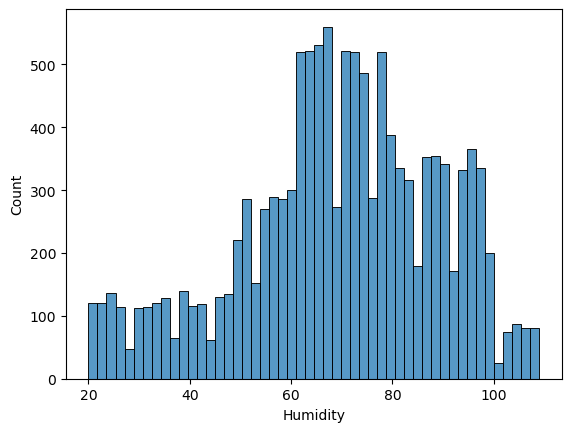

In [70]:
sns.histplot(data = df, x = 'Humidity', bins = 50)

In [72]:
df['Humidity'].skew()

-0.42640855973186

In [74]:
len_b = len(df)
len_a = len(df[ df['Humidity'] > 100])
print(len_b , len_a )

12343 347


In [76]:
df = df[ df['Humidity'] <= 100]

<Axes: xlabel='Precipitation (%)', ylabel='Count'>

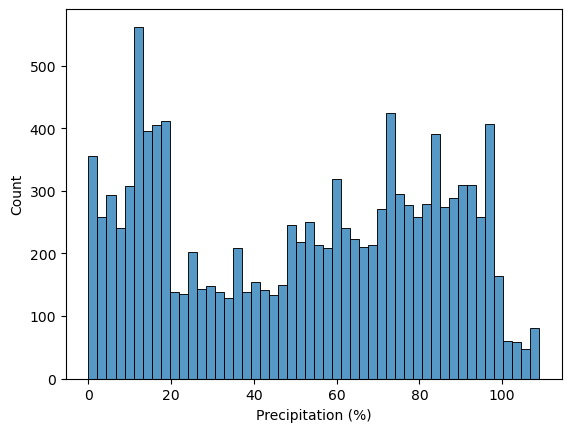

In [78]:
sns.histplot(data = df, x = 'Precipitation (%)', bins = 50)

In [80]:
df['Precipitation (%)'].skew()

-0.08881579847755515

In [82]:
len_b = len(df)
len_a = len(df[ df['Precipitation (%)'] > 100])
print(len_b , len_a , (len_a / len_b) *100)

11996 248 2.067355785261754


In [84]:
df = df[ df['Precipitation (%)'] <= 100]

In [86]:
df.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Was_Rain,cloud_cover,Season_Autumn,Season_Spring,Season_Summer,Season_Winter,Location_coastal,Location_inland,Location_mountain
count,11748.000000,11748.000000,11748.000000,11748.000000,11748.00000,11748.000000,11748.000000,11748.000000,11748.000000,11748.000000,11748.000000,11748.000000,11748.000000,11748.000000,11748.000000,11748.000000
mean,18.228635,67.709312,9.394663,50.597463,1004.53759,3.622404,5.332397,0.250511,1.792475,0.185053,0.193990,0.185734,0.435223,0.265662,0.365339,0.368999
std,15.359465,19.092148,6.336469,31.148556,19.92917,3.605315,3.058633,0.433326,1.196817,0.388357,0.395438,0.388908,0.495807,0.441704,0.481546,0.482554
min,-20.000000,20.000000,0.000000,0.000000,870.05000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,18.000000,994.91000,1.000000,3.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,21.000000,69.000000,8.500000,54.000000,1007.22500,2.000000,5.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,30.000000,82.000000,13.000000,79.000000,1016.21000,6.000000,7.500000,1.000000,3.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
max,55.000000,100.000000,48.500000,100.000000,1082.99000,14.000000,20.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Correlation

In [208]:
weathercorr = df.corr(method = 'pearson')
weathercorr

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Was_Rain,cloud_cover,Season_Autumn,Season_Spring,Season_Summer,Season_Winter,Location_coastal,Location_inland,Location_mountain
Temperature,1.000000,-0.383934,-0.150278,-0.471798,0.443410,0.448855,0.362167,0.143778,-0.460735,0.213085,0.209241,0.215465,-0.502798,0.256105,-0.119600,-0.115075
Humidity,-0.383934,1.000000,0.384821,0.651683,-0.236273,-0.486258,-0.527101,0.328803,0.482594,-0.108130,-0.103651,-0.101851,0.247257,-0.115510,0.060405,0.045453
Wind Speed,-0.150278,0.384821,1.000000,0.440906,-0.139020,-0.161439,-0.333975,0.343504,0.277082,-0.028367,-0.042839,-0.025396,0.076306,-0.025617,0.023522,-0.000024
Precipitation (%),-0.471798,0.651683,0.440906,1.000000,-0.396584,-0.454916,-0.547913,0.438212,0.548002,-0.124038,-0.126135,-0.121893,0.293369,-0.137097,0.065061,0.060566
Atmospheric Pressure,0.443410,-0.236273,-0.139020,-0.396584,1.000000,0.256202,0.181067,-0.026856,-0.348828,0.122338,0.107079,0.109766,-0.267327,0.131293,-0.060171,-0.060133
UV Index,0.448855,-0.486258,-0.161439,-0.454916,0.256202,1.000000,0.448258,-0.231622,-0.518466,0.118978,0.111213,0.114986,-0.272087,0.126824,-0.057583,-0.058625
Visibility (km),0.362167,-0.527101,-0.333975,-0.547913,0.181067,0.448258,1.000000,-0.367084,-0.400885,0.124009,0.125103,0.111584,-0.284438,0.120577,-0.061852,-0.048647
Was_Rain,0.143778,0.328803,0.343504,0.438212,-0.026856,-0.231622,-0.367084,1.000000,0.279499,0.078099,0.087976,0.091625,-0.203210,0.138390,-0.053522,-0.073265
cloud_cover,-0.460735,0.482594,0.277082,0.548002,-0.348828,-0.518466,-0.400885,0.279499,1.000000,-0.118288,-0.097501,-0.104100,0.252071,-0.118410,0.057562,0.050945
Season_Autumn,0.213085,-0.108130,-0.028367,-0.124038,0.122338,0.118978,0.124009,0.078099,-0.118288,1.000000,-0.233778,-0.227586,-0.418312,0.097987,-0.043812,-0.045972


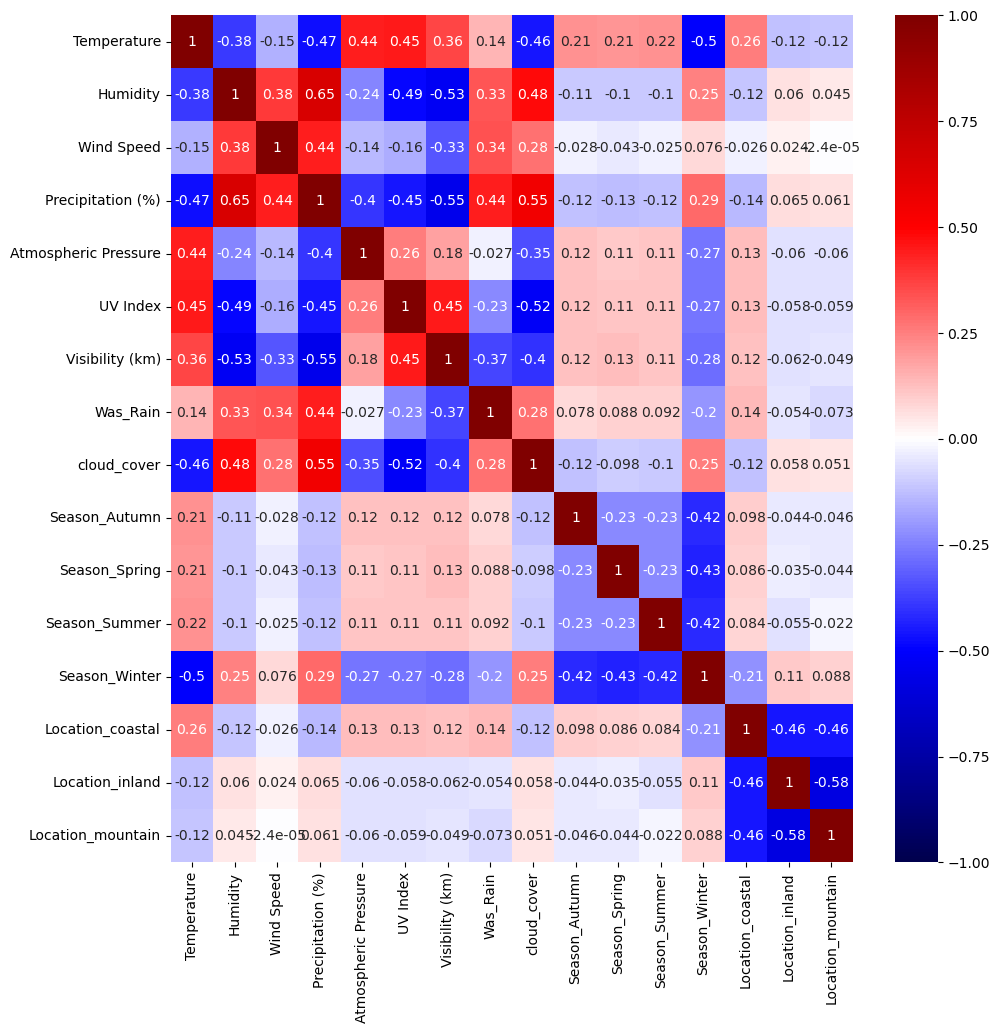

In [209]:
plt.figure(figsize = (11,11))
sns.heatmap(weathercorr, vmin=-1, vmax=1, annot = True, cmap = 'seismic')
plt.show()

<Axes: xlabel='Humidity', ylabel='Precipitation (%)'>

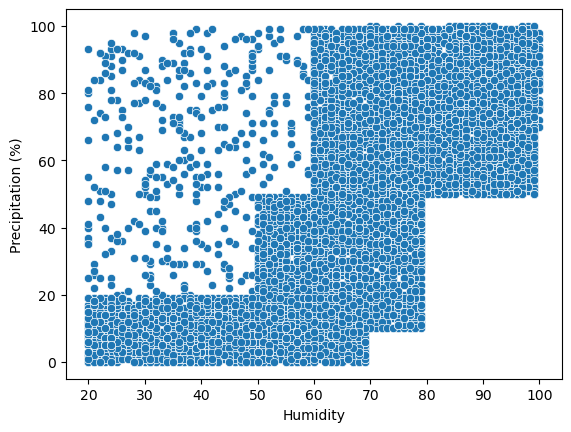

In [210]:
sns.scatterplot( x = 'Humidity' , y = 'Precipitation (%)' , data = df)

<Axes: xlabel='cloud_cover', ylabel='Precipitation (%)'>

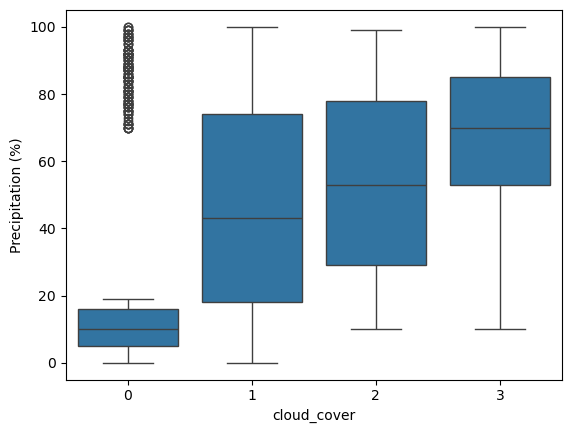

In [211]:
sns.boxplot( x = 'cloud_cover' , y = 'Precipitation (%)' , data = df)

<Axes: xlabel='Was_Rain', ylabel='Precipitation (%)'>

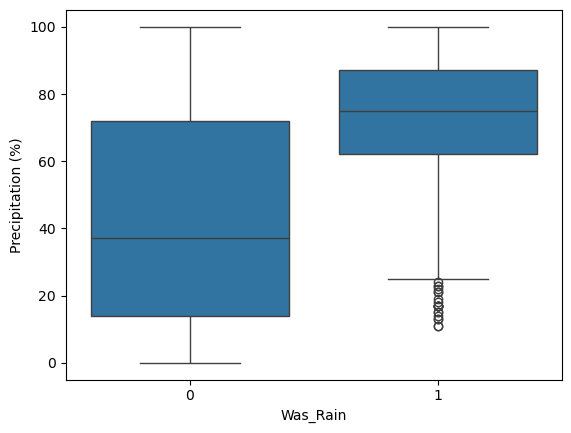

In [212]:
sns.boxplot( x = 'Was_Rain' , y = 'Precipitation (%)' , data = df)

<Axes: xlabel='cloud_cover', ylabel='Humidity'>

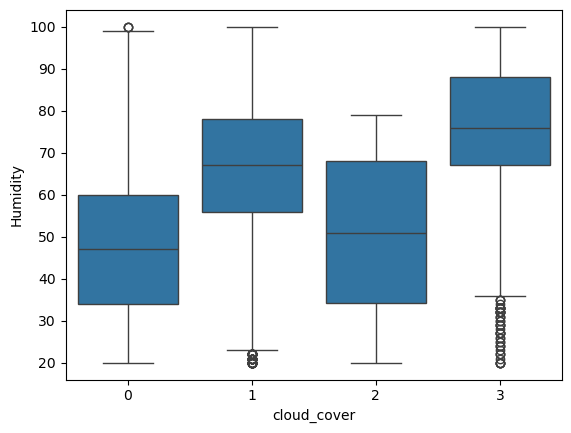

In [213]:
sns.boxplot( x = 'cloud_cover' , y = 'Humidity' , data = df)

<Axes: xlabel='cloud_cover', ylabel='Temperature'>

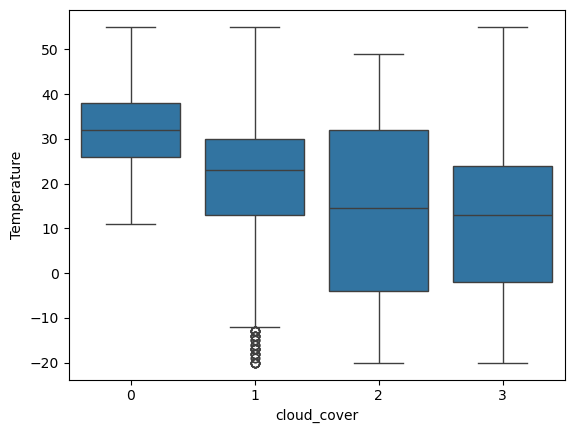

In [214]:
sns.boxplot( x = 'cloud_cover' , y = 'Temperature' , data = df)

<Axes: xlabel='Season_Winter', ylabel='Temperature'>

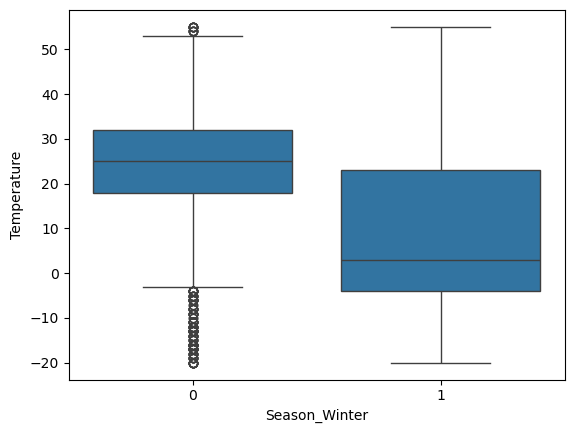

In [215]:
sns.boxplot( x = 'Season_Winter' , y = 'Temperature' , data = df)

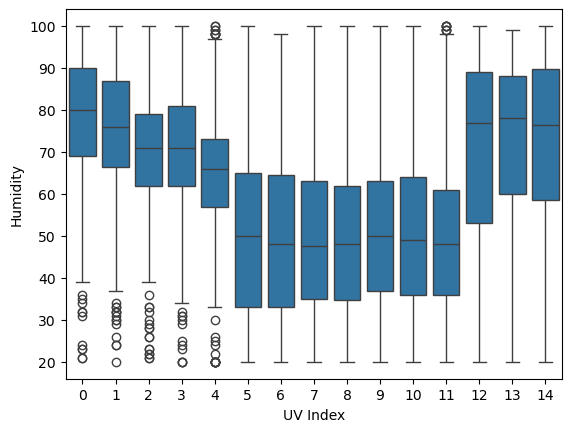

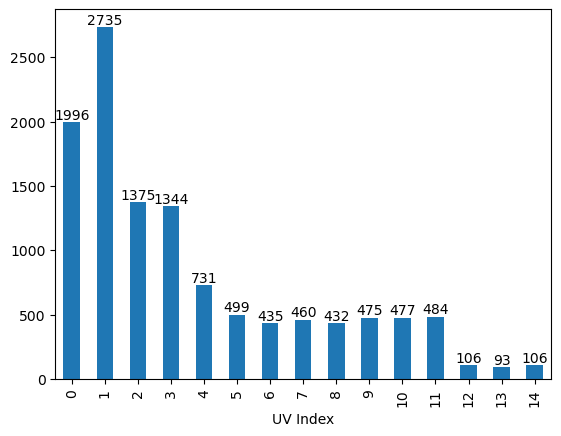

In [216]:
sns.boxplot( y = 'Humidity' , x = 'UV Index' , data = df)
plt.show()
UV_counts = df['UV Index'].value_counts().sort_index()
ax = UV_counts.plot(kind="bar")
ax.bar_label(ax.containers[0])
plt.show()

Humidity and UV Index looks to have negative correlation as when UV Increases, Humidity decreases. However for UV Index 12, 13 and 14 this isnt the case. Looking at the counts for these index, they are extreme events which occur less often. This would play a part in their average humidity being higher than expected.

<Axes: xlabel='cloud_cover', ylabel='UV Index'>

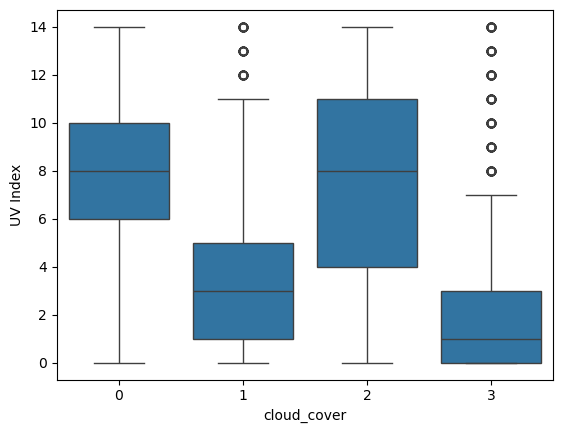

In [218]:
sns.boxplot( x = 'cloud_cover' , y = 'UV Index' , data = df)